In [1]:
import os
from IPython.display import clear_output


notebook_dir = "/home/balabaevvl/courses/nlp/nlp_course/week11_interpretability"  # notebook's dir

os.chdir(notebook_dir)

GPUs = [
    "GPU-e83bd31b-fcb9-b8de-f617-2d717619413b",
    "GPU-5a9b7750-9f85-49a5-3aae-fe07b1b7661d",
    "GPU-fe2d8dfd-06f2-a5c4-a7fd-4a5f23947005",
    "GPU-0c320096-21ee-4060-8731-826ca2febfab",
    "GPU-baef952c-6609-aace-3b78-e4e07788d5de",
    "GPU-3979d65b-c238-4e9c-0c1c-1aa3f05c56a1",
    "GPU-6c76a2c5-5375-aa06-11d4-0fddfac30e91",
]
os.environ["CUDA_VISIBLE_DEVICES"] = f"{GPUs[2]}"


In [2]:
import os

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"       # !pip install -U hf_transfer
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"    # problems with progress bar

# import shutil
# from huggingface_hub.constants import HF_HUB_CACHE

# cache = os.path.expanduser(HF_HUB_CACHE)
# model_to_delete = "models--unsloth--Llama-3.2-3B"

# for d in os.listdir(cache):
#     if d.startswith(model_to_delete):
#         shutil.rmtree(os.path.join(cache, d), ignore_errors=True)
#         print(f"Deleted {d}")


# --- DELETE ALL CACHE ---
# import os, shutil
# from huggingface_hub import scan_cache_dir
# from huggingface_hub.constants import HF_HUB_CACHE

# cache_info = scan_cache_dir()   # Scans everything in ~/.cache/huggingface/hub

# for repo in cache_info.repos:
#     print(f"Deleting cache for: {repo.repo_id}")
#     shutil.rmtree(repo.repo_path, ignore_errors=True)


# Homework: Sentiment Steering and Sparse Autoencoders

This assignment explores two mechanistic interpretability techniques:

1. Sentiment steering via activation addition. 
2. Sparse autoencoder on model activations. 

In [6]:
!pip install torch matplotlib transformer_lens transformers datasets

clear_output()


In [3]:
import torch
import numpy as np
from transformer_lens import HookedTransformer


device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HookedTransformer.from_pretrained('gpt2').to(device)


`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda


## Part 1 – Sentiment Steering via residual (3 points)

Your task is to steer model into good/bad generations and see the results.

In [8]:
# This is enough to steer! You may experiment with dataset as you want
positive_sentences = [
    'I love this product, it works wonderfully!',
    'This is the best day I have ever had.',
    'I am feeling fantastic and everything is great.',
    'What a delightful surprise!',
    'The food was amazing and the service was excellent.'
]

negative_sentences = [
    'I hate this product, it is terrible.',
    'This is the worst day of my life.',
    'I am feeling awful and everything is bad.',
    'What a horrible experience.',
    'The food was disgusting and the service was terrible.'
]

positive_tokens = model.to_tokens(positive_sentences).to(device)
negative_tokens = model.to_tokens(negative_sentences).to(device)


In [41]:
# Function to collect average residual activations for a list of sentences
def collect_average_residuals(sent_list: list[str]):
    layers = model.cfg.n_layers

    with torch.no_grad():
        _, cache = model.run_with_cache(sent_list)

    avgs = {}
    for layer in range(layers):
        hook_name = f"blocks.{layer}.hook_resid_pre"
        avgs[hook_name] = cache[hook_name].mean(dim=(0, 1)) # average over batch and positions (of sequence embeddings)

    return avgs

pos_avgs = collect_average_residuals(positive_sentences)
neg_avgs = collect_average_residuals(negative_sentences)

steering_vectors = {hook_name: pos_avgs[hook_name] - neg_avgs[hook_name] for hook_name in pos_avgs.keys()}

In [57]:
def top_k_sampling(logits, k=50):
    values, indices = torch.topk(logits, k)
    probs = torch.softmax(values, dim=-1)
    next_token = indices[torch.multinomial(probs, num_samples=1)]
    return next_token


# Function to generate text with steering applied
def generate_with_steering(prompt, max_new_tokens=20, coef=0.0):
    def steering_hook(value, hook):
        value += coef * steering_vectors[hook.name]
        return value

    hooks = [(hook_name, steering_hook) for hook_name in steering_vectors.keys()]

    tokens = model.to_tokens(prompt).to(device)

    for _ in range(max_new_tokens):
        with torch.no_grad():
            logits = model.run_with_hooks(tokens, fwd_hooks=hooks)
        
        logits = logits[0, -1]

        # next_token = logits.argmax().unsqueeze(0)
        next_token = top_k_sampling(logits, k=10)
        tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)

        if next_token == model.tokenizer.eos_token_id:
            break

    return model.to_string(tokens[0, 1:])

prompt = 'The movie that I watched yesterday was'
print('Neutral completion:')
print(generate_with_steering(prompt, max_new_tokens=20, coef=0.0))
print('\nPositive-steered completion:')
print(generate_with_steering(prompt, max_new_tokens=20, coef=0.3))
print('\nNegative-steered completion:')
print(generate_with_steering(prompt, max_new_tokens=20, coef=-0.3))


Neutral completion:
The movie that I watched yesterday was The Matrix, and it's pretty cool. It's like The Matrix. It's a bunch of

Positive-steered completion:
The movie that I watched yesterday was a wonderful piece of work with a really nice cast and I'm happy to have it for my family

Negative-steered completion:
The movie that I watched yesterday was a bad movie about the death of an American soldier. That doesn't make it right, though.


You should see how this is much more effective than tinkering with attantion heads from seminar.

## Part 2 – Sparse Autoencoder on Residual Activations (4 + bonus)

This is compute intensive part and you may adjust hyperparameters to your liking. Try to get meaningful results but in the end it might be compute bound. You still can get max points.


In [4]:
from datasets import load_dataset


ds = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
texts = ds["text"]

texts = [t for t in texts if len(t.strip()) > 0]
dataset_sentences = texts[:10000] # You may want to adjust here

print("Total lines:", len(dataset_sentences))


Total lines: 10000


In [ ]:
from tqdm import tqdm 


last_layer = model.cfg.n_layers - 1

activations = []
token_to_sentence = []

for sent_id, sent in tqdm(enumerate(dataset_sentences)):
    tokens = model.to_tokens(sent).to(device)

    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)

    # Take the *residual stream* at the last layer
    resid = cache[f"blocks.{last_layer}.hook_resid_pre"]
    activations.append(resid.squeeze(0))
    token_to_sentence.extend([sent_id] * resid.shape[1]) # store sent_id per activated token

activations = torch.cat(activations, dim=0)
token_to_sentence = torch.tensor(token_to_sentence)
print('Activation dataset shape:', activations.shape)


Activation dataset shape: torch.Size([1012369, 768])


In [12]:
torch.save(activations, "activations.pt")
torch.save(token_to_sentence, "token_to_sentence.pt")


#### Your task is to use any SAE try to disentangle features from residual. In the end you will look at top sentences that activate certain features.

Classic approach is enc + relu + dec \
For loss: mse + coef * l1 on hiddden \
But feel free to experiment!

In [6]:
activations = torch.load("activations.pt")
token_to_sentence = torch.load("token_to_sentence.pt")


In [7]:
import torch.nn as nn


class SAE(nn.Module):
    """Sparse AutoEncoder"""
    
    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        
        self.encoder = nn.Linear(input_dim, hidden_dim, bias=True)
        self.decoder = nn.Linear(hidden_dim, input_dim, bias=True)

    def forward(self, x):
        z = self.encoder(x)
        z = torch.relu(z)

        x_hat = self.decoder(z)
        
        return x_hat, z


In [45]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(activations)
loader = DataLoader(dataset, batch_size=1024, shuffle=False)


In [46]:
input_dim = activations.shape[1]
hidden_dim = input_dim * 16
learning_rate = 3e-4
num_epochs = 1
l1_coef = 20

l2_coef = 1

sae = SAE(input_dim, hidden_dim).to(device)
optimizer = torch.optim.Adam(sae.parameters(), lr=learning_rate)
mse = nn.MSELoss()


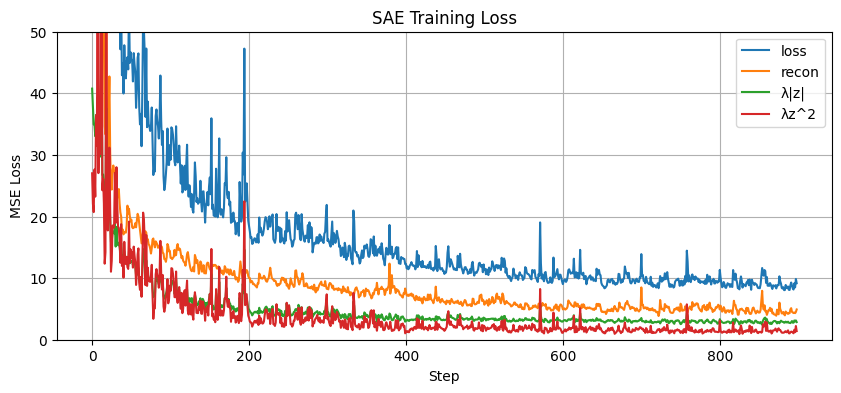

In [47]:
import matplotlib.pyplot as plt

recon_history = []
l1_history = []
l2_history = []
loss_history = []
plot_every = 100

step = 1

sae.train()

for epoch in range(num_epochs):
    for (activation_batch,) in loader:

        optimizer.zero_grad()

        activation_batch_hat, z = sae(activation_batch)

        recon_loss = mse(activation_batch, activation_batch_hat)
        l1_loss = l1_coef * z.abs().mean()
        
        l2_loss = l2_coef * (z ** 2).mean()

        # loss = recon_loss + l1_loss
        loss = recon_loss + l1_loss + l2_loss

        loss.backward()
        optimizer.step()

        recon_history.append(recon_loss.item())
        l1_history.append(l1_loss.item())
        l2_history.append(l2_loss.item())
        loss_history.append(loss.item())

        step += 1
        if step % plot_every == 0:
            clear_output(True)
            
            plt.figure(figsize=(10, 4))
            plt.plot(loss_history, label="loss")
            plt.plot(recon_history, label="recon")
            plt.plot(l1_history, label="λ|z|")
            plt.plot(l2_history, label="λz^2")
            plt.legend()
            plt.xlabel("Step")
            plt.ylabel("MSE Loss")
            plt.title("SAE Training Loss")
            plt.ylim(0, 50)
            plt.grid(True)
            plt.show()


In [48]:
(activation_batch,) = next(iter(loader))
activation_batch = activation_batch.to(device)

with torch.no_grad():
    _, z = sae(activation_batch)

threshold = 0.1
frac_active = (z > threshold).float().mean().item()
mean_abs_z = z.abs().mean().item()
max_z = z.max().item()

print(f"Fraction of active units: {frac_active:.3f}")
print(f"Mean |z|: {mean_abs_z:.3f}")
print(f"Max z:   {max_z:.3f}\n")

print(f"Reconstruction Loss: {recon_history[-1]:.3f}")
print(f"λ|z| Loss: {l1_history[-1]:.3f}")
print(f"λz^2 Loss: {l2_history[-1]:.3f}")
print(f"Total Loss: {loss_history[-1]:.3f}")


Fraction of active units: 0.056
Mean |z|: 0.152
Max z:   99.600

Reconstruction Loss: 3.960
λ|z| Loss: 3.230
λz^2 Loss: 2.258
Total Loss: 9.448


Below is some code that prints tokens that activate certain neuron the most. You are free to change it!

In [49]:
NUM_BATCHES = 100

z = []

sae.eval()

for i, (activation_batch,) in enumerate(loader):
    if i >= NUM_BATCHES:
        break

    with torch.no_grad():
        _, z_ = sae(activation_batch)

    z.append(z_.cpu().numpy())

z = np.concatenate(z, axis=0)


In [51]:
# For selected neuron indices, find the sentences with highest activation
selected_neurons = [2, 10, 18]


for neuron in selected_neurons:
    activations_neuron = z[:, neuron]
    top_idx = activations_neuron.argsort()[::-1][:5]
    print(f'Neuron {neuron}:')

    for rank, idx in enumerate(top_idx, start=1):
        sent_id = token_to_sentence[idx].item()
        text = dataset_sentences[sent_id]

        toks = model.to_tokens(text)[0, 1:]
        str_toks = model.to_str_tokens(toks)

        token_positions = (token_to_sentence == sent_id).nonzero(as_tuple=True)[0]
        local_pos = (token_positions == idx).nonzero(as_tuple=True)[0].item()

        start = local_pos - 5
        if start < 0:
            cropped = "".join(str_toks[:local_pos + 1])
        else:
            cropped = "... " + "".join(str_toks[local_pos - 5:local_pos + 1])
        

        print(f"Top {rank}: global token {idx}, sentence {sent_id}, local token {local_pos}")
        print(cropped)
        print()

Neuron 2:
Top 1: global token 51800, sentence 550, local token 105
...  aircraft only ) , and Unlimited

Top 2: global token 94466, sentence 936, local token 363
...  . There are many divin

Top 3: global token 95406, sentence 940, local token 292
...  , a galaxy of divin

Top 4: global token 41410, sentence 466, local token 264
...  recognized the unity of the divine

Top 5: global token 51944, sentence 553, local token 19
...  take place , although more specific

Neuron 10:
Top 1: global token 16528, sentence 237, local token 321
...  rumors that Head Coach Scott Arn

Top 2: global token 77552, sentence 796, local token 47
...  uses history as a starting point

Top 3: global token 40636, sentence 462, local token 181
...  is further complicated by Aten

Top 4: global token 15515, sentence 230, local token 39
...  start , Head Coach Scott Arn

Top 5: global token 40571, sentence 462, local token 116
...  existing religious beliefs , Aten

Neuron 18:
Top 1: global token 74798, sentence